# Preprocessing and exploratory data analysis (EDA) on the TDC Acute Toxicity LD50 dataset

This notebook:
1. Loads the dataset and inspects its structure.
2. Checks for missing values and removes rows without a valid target.
3. Examines the 'Drug' column (contains SMILES) and identifies duplicate SMILES.
4. Aggregates multiple measurements for the same SMILES using the median (justification given).
5. Performs exploratory data analysis on the target variable Y (already in −log₁₀(mol/kg)).
6. Computes molecular weights for further exploration.

In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 54.8 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the dataset

In [24]:
file_path = '/content/drive/MyDrive/FYP/IRP/Data/TD Commons LD50/LD50_Zhu_train.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5170, 3)


,Drug_ID,Drug,Y
0,"Methane, tribromo-",BrC(Br)Br,2.343
1,Bromoethene (9CI),C=CBr,2.330
2,"1,1'-Biphenyl, hexabromo-",Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
3,"Isothiocyanic acid, p-bromophenyl ester",S=C=Nc1ccc(Br)cc1,2.729
4,"Benzene, bromo-",Brc1ccccc1,1.765


## 2. Initial inspection and cleaning

In [25]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5170 entries, 0 to 5169
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Drug_ID  5170 non-null   object 
 1   Drug     5170 non-null   object 
 2   Y        5170 non-null   float64
dtypes: float64(1), object(2)
memory usage: 121.3+ KB


In [26]:
# The 'Drug' column should contain SMILES; 'Y' is the target value.
# Confirm that Y is numeric.
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
print(f"Non‑numeric Y values dropped: {df['Y'].isna().sum()}")

Non‑numeric Y values dropped: 0


In [27]:
# Drop rows with missing Y
df = df.dropna(subset=['Y']).copy()

In [28]:
# Check for missing SMILES
print(f"Missing SMILES: {df['Drug'].isna().sum()}")
df = df.dropna(subset=['Drug']).copy()

Missing SMILES: 0


In [29]:
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (5170, 3)


## 3. Check duplicates in SMILES

In [30]:
# Count unique SMILES
print(f"Unique SMILES: {df['Drug'].nunique()}")

# Show duplicated SMILES
duplicated_smiles = df[df.duplicated('Drug', keep=False)]
print(f"Number of rows with duplicated SMILES: {len(duplicated_smiles)}")
duplicated_smiles.sort_values('Drug').head(10)

Unique SMILES: 5138
Number of rows with duplicated SMILES: 60


,Drug_ID,Drug,Y
1630,"Methacrylaldehyde, O-(methylcarbamoyl)oxime",C=C(C)C=NOC(=O)NC,2.977
3249,Mercarbenil,C=C(C)C=NOC(=O)NC,3.255
4026,"9,10-Secocholesta-5,7,10(19)-triene-1,3-diol, ...",C=C1C(=CC=C2CCCC3(C)C2CCC3C(C)CCCC(C)C)CC(O)CC1O,6.071
2734,"9,10-Secocholesta-5,7,10(19)-triene-1,3-diol, ...",C=C1C(=CC=C2CCCC3(C)C2CCC3C(C)CCCC(C)C)CC(O)CC1O,3.071
3797,"1H-1,2,4-Triazole-1-ethanol, beta-((4-chloroph...",CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1)n1cncn1,2.832
3804,"1H-1,2,4-Triazole-1-ethanol, beta-((4-chloroph...",CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1)n1cncn1,2.212
3800,"1H-1,2,4-Triazole-1-ethanol, beta-((2,4-dichlo...",CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1Cl)n1cncn1,2.838
3808,"1H-1,2,4-Triazole-1-ethanol, beta-((2,4-dichlo...",CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1Cl)n1cncn1,2.838
3419,"(E)-?-[(2,4-dichlorophenyl)methylene]-?-(1,1-d...",CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1Cl)n1cncn1,2.838
2803,Neopinamine,CC(C)=CC1C(C(=O)OCN2C(=O)C3=C(CCCC3)C2=O)C1(C)C,1.830


## 4. Aggregate multiple measurements per SMILES (median)

**Justification**: LD50 values are typically log‑normally distributed, so the median (or geometric mean) is a robust central estimate that is less sensitive to outliers than the arithmetic mean. Using the median on the already log‑transformed Y is equivalent to taking the median on the original scale, which preserves the location of the distribution without assuming a parametric form. This approach follows common practice in QSAR datasets (Karmaus et al., 2022).


In [31]:
# Group by SMILES and compute median of Y
agg_df = df.groupby('Drug').agg(
    Y_median=('Y', 'median'),                 # median of the target
    Drug_ID_first=('Drug_ID', 'first'),       # first Drug_ID for reference
    n_measurements=('Drug_ID', 'count')       # count of original measurements (any column works)
).reset_index()

# Rename columns for clarity (optional)
agg_df = agg_df.rename(columns={'Y_median': 'Y'})

print(f"Number of unique compounds after aggregation: {len(agg_df)}")
agg_df.head()

# Show how many compounds have multiple measurements
agg_df['n_measurements'].describe()

Number of unique compounds after aggregation: 5138


,n_measurements
count,5138.000000
mean,1.006228
std,0.090206
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


## 5. Exploratory Data Analysis on Y

In [32]:
# Basic statistics of Y
print("Statistics of Y (‑log₁₀(mol/kg)):")
print(agg_df['Y'].describe())

Statistics of Y (‑log₁₀(mol/kg)):
count    5138.000000
mean        2.535449
std         0.959027
min        -0.343000
25%         1.852250
50%         2.364500
75%         3.022750
max        10.207000
Name: Y, dtype: float64


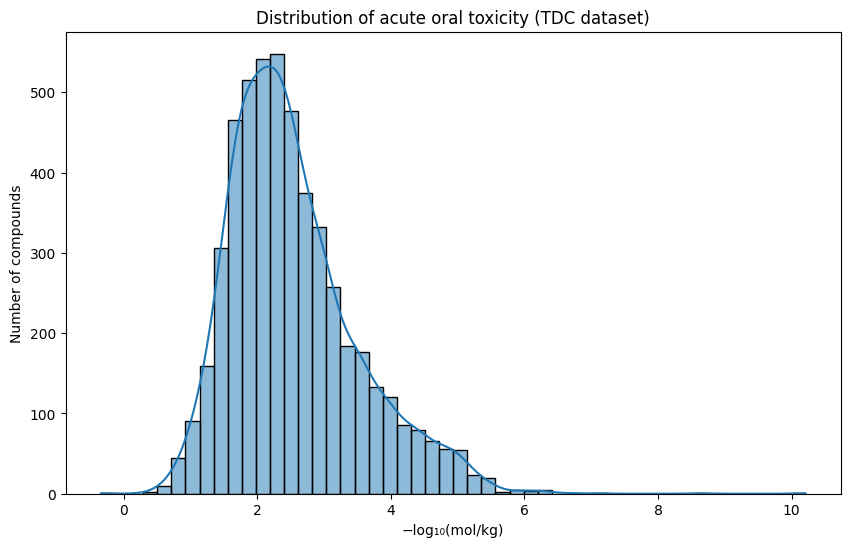

In [33]:
# Histogram
plt.figure(figsize=(10,6))
sns.histplot(agg_df['Y'], bins=50, kde=True)
plt.xlabel('−log₁₀(mol/kg)')
plt.ylabel('Number of compounds')
plt.title('Distribution of acute oral toxicity (TDC dataset)')
plt.show()

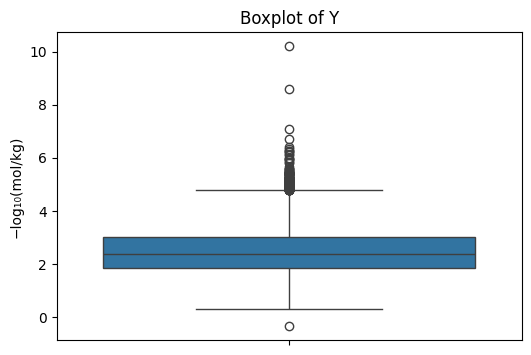

In [34]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=agg_df['Y'])
plt.ylabel('−log₁₀(mol/kg)')
plt.title('Boxplot of Y')
plt.show()

## 6. Compute molecular weights for further analysis

In [38]:
# Molecular weight can be derived from SMILES to explore possible relationships with toxicity.

# %% [code]
def mol_weight_from_smiles(smiles):
    """Calculate molecular weight from SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Descriptors.MolWt(mol)

agg_df['MW'] = agg_df['Drug'].apply(mol_weight_from_smiles)
print(f"Number with valid MW: {agg_df['MW'].notna().sum()}")

# Drop any rows where MW could not be computed (optional, but recommended)
agg_df = agg_df.dropna(subset=['MW']).copy()

Number with valid MW: 5138


## 7. Save the processed dataset

In [39]:
output_path = '/content/drive/MyDrive/FYP/IRP/Data/TD Commons LD50/LD50_Zhu_train_processed.csv'
agg_df.to_csv(output_path, index=False)
print(f"Saved processed data to {output_path}")

# For modeling, keep only SMILES and Y
model_ready = agg_df[['Drug', 'Y']].copy()
model_ready.to_csv('/content/drive/MyDrive/FYP/IRP/Data/TD Commons LD50/LD50_Zhu_model_ready.csv', index=False)

Saved processed data to /content/drive/MyDrive/FYP/IRP/Data/TD Commons LD50/LD50_Zhu_train_processed.csv
